In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/DetectLLM/DetectLLM-main

/content/drive/MyDrive/DetectLLM/DetectLLM-main


In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
CUDA Device Count: 1
GPU: Tesla T4


In [ ]:
import os
import shutil

repo_path = '/content/DetectLLM'

if os.path.exists(repo_path):
    print(f"Removing existing directory: {repo_path}")
    shutil.rmtree(repo_path)

print(f"Cloning DetectLLM repository to {repo_path}...")
!git clone https://github.com/mbzuai-nlp/DetectLLM.git {repo_path}

%cd {repo_path}

if os.path.exists(repo_path):
    print(f"Successfully cloned and changed directory to: {os.getcwd()}")
else:
    print(f"Error: {repo_path} was not created.")


Cloning DetectLLM repository to /content/DetectLLM...
Cloning into '/content/DetectLLM'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 68 (delta 16), reused 42 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 2.54 MiB | 6.43 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/DetectLLM
Successfully cloned and changed directory to: /content/DetectLLM


In [ ]:
import argparse
import os
import json
from baselines.utils.preprocessing import preprocess_and_save
from baselines.utils.loadmodel import load_base_model_and_tokenizer, load_mask_filling_model
from baselines.sample_generate.generate import generate_data
from baselines.all_baselines import run_all_baselines



if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--dataset', type=str, default="xsum")
    parser.add_argument('--dataset_key', type=str, default="document")
    parser.add_argument('--pct_words_masked', type=float, default=0.3)
    parser.add_argument('--span_length', type=int, default=2)
    parser.add_argument('--n_samples', type=int, default=200)
    parser.add_argument('--n_perturbation_list', type=str, default="5")
    parser.add_argument('--n_perturbation_rounds', type=int, default=1)
    parser.add_argument('--base_model_name', type=str, default="gpt2-medium")
    parser.add_argument('--scoring_model_name', type=str, default="")
    parser.add_argument('--mask_filling_model_name', type=str, default="t5-small")
    parser.add_argument('--batch_size', type=int, default=50)
    parser.add_argument('--chunk_size', type=int, default=20)
    parser.add_argument('--n_similarity_samples', type=int, default=20)
    parser.add_argument('--int8', action='store_true')
    parser.add_argument('--half', action='store_true')
    parser.add_argument('--base_half', action='store_true')
    parser.add_argument('--do_top_k', action='store_true')
    parser.add_argument('--top_k', type=int, default=40)
    parser.add_argument('--do_top_p', action='store_true')
    parser.add_argument('--top_p', type=float, default=0.96)
    parser.add_argument('--output_name', type=str, default="default_run") # Changed default
    parser.add_argument('--openai_model', type=str, default=None)
    parser.add_argument('--openai_key', type=str)
    parser.add_argument('--DEVICE', type=str, default ='cuda')
    parser.add_argument('--buffer_size', type=int, default=1)
    parser.add_argument('--mask_top_p', type=float, default=1.0)
    parser.add_argument('--pre_perturb_pct', type=float, default=0.0)
    parser.add_argument('--pre_perturb_span_length', type=int, default=5)
    parser.add_argument('--random_fills', action='store_true')
    parser.add_argument('--random_fills_tokens', action='store_true')
    parser.add_argument('--cache_dir', type=str, default="./cache")
    parser.add_argument('--dataset_seed', type=int, default=0)
    parser.add_argument('--n_detectors', type=int, default=1)
    parser.add_argument('--num_tokens_to_mask', type=int, default=0)
    parser.add_argument('--mae_samples', type=int, default=5000)
    parser.add_argument('--n_generations', type=int, default=1)
    parser.add_argument('--generation_len', type=int, default=200)
    parser.add_argument('--min_words', type=int, default=55)
    parser.add_argument('--min_len', type=int, default=150)
    parser.add_argument('--temperature', type=float, default=1)
    parser.add_argument('--baselines', type=str, default="DetectGPT,NPR")
    args, unknown = parser.parse_known_args()


    print(f"DEBUG (main.py): args.dataset: {args.dataset}")
    print(f"DEBUG (main.py): args.output_name: {args.output_name}")


    mask_filling_model_name = args.mask_filling_model_name
    n_samples = args.n_samples
    batch_size = args.batch_size
    n_perturbation_list = [int(x) for x in args.n_perturbation_list.split(",")]
    n_perturbation_rounds = args.n_perturbation_rounds
    n_similarity_samples = args.n_similarity_samples

    cache_dir, base_model_name, SAVE_FOLDER = preprocess_and_save(args)


    print(f"DEBUG (main.py): SAVE_FOLDER after preprocess_and_save: {SAVE_FOLDER}")


    model_config ={}
    model_config['cache_dir'] = cache_dir

    model_config = load_base_model_and_tokenizer(args, model_config)


    model_config = load_mask_filling_model(args, mask_filling_model_name, model_config)
    print(f'Loading dataset {args.dataset}...')
    data = generate_data(args, model_config)

    baselines = [x for x in args.baselines.split(',')]
    baseline_outputs = run_all_baselines(data, args, n_perturbation_list, model_config, baselines= baselines)
    if not os.path.exists(SAVE_FOLDER):
        os.makedirs(SAVE_FOLDER)
    print(f"Saving results to absolute path: {os.path.abspath(SAVE_FOLDER)}")

    with open(os.path.join(SAVE_FOLDER, "result.json"), "w") as f:
        json.dump(baseline_outputs, f, indent=4)


### Inspecting `baselines/all_baselines.py`

In [ ]:
from baselines.loss import get_ll, get_lls
from baselines.detectGPT import perturb_texts
from baselines.rank import get_ranks, get_rank
from baselines.entropy import get_entropy
from baselines.supervised import eval_supervised
import torch
import numpy as np
import tqdm
import functools
from baselines.utils.run_baseline import get_roc_metrics, get_precision_recall_metrics, get_accurancy, run_baseline_threshold_experiment
import math
def run_all_baselines(data, args, n_perturbation_list, model_config, baselines = ['likelihood','logrank','simple', 'perturb_prob','perturb_logrank']):
    torch.manual_seed(0)
    np.random.seed(0)
    original_text = data["original"]
    sampled_text = data["sampled"]
    results = []
    if ('DetectGPT' in baselines) or ('NPR' in baselines):
        perturb_fn = functools.partial(perturb_texts, args=args, model_config= model_config)
        p_sampled_text = perturb_fn([x for x in sampled_text for _ in range(max(n_perturbation_list))])
        p_original_text = perturb_fn([x for x in original_text for _ in range(max(n_perturbation_list))])
        for idx in range(len(original_text)):
            results.append({
                "original": original_text[idx],
                "sampled": sampled_text[idx],
                "perturbed_sampled": p_sampled_text[idx * max(n_perturbation_list): (idx + 1) * max(n_perturbation_list)],
                "perturbed_original": p_original_text[idx * max(n_perturbation_list): (idx + 1) * max(n_perturbation_list)]
            })
    else:
        for idx in range(len(original_text)):
            results.append({
                "original": original_text[idx],
                "sampled": sampled_text[idx]
            })
    if ('likelihood' in baselines) or ('DetectGPT' in baselines) or ('LRR' in baselines):
        for res in tqdm.tqdm(results, desc="Computing unperturbed log likelihoods"):
            orig_ll = get_ll(res["original"],args, model_config)
            samp_ll = get_ll(res["sampled"], args, model_config)
            res["original_ll"] = orig_ll if np.isfinite(orig_ll) else 0.0 # Ensure finite
            res["sampled_ll"] = samp_ll if np.isfinite(samp_ll) else 0.0 # Ensure finite

    if ('logrank' in baselines) or ('NPR' in baselines) or ('simple' in baselines):
        for res in tqdm.tqdm(results, desc="Computing unperturbed log rank"):
            orig_logrank = get_rank(res["original"], args, model_config, log =  True)
            samp_logrank = get_rank(res["sampled"], args, model_config, log =  True)
            res["original_logrank"] = orig_logrank if np.isfinite(orig_logrank) else 0.0 # Ensure finite
            res["sampled_logrank"] = samp_logrank if np.isfinite(samp_logrank) else 0.0 # Ensure finite

    if ('perturb_prob' in baselines) or ('DetectGPT' in baselines) or ('LRR' in baselines):
        for n_perturbation in n_perturbation_list:
            for res in tqdm.tqdm(results, desc=f"Computing perturbed log likelihoods with n_perturbation={n_perturbation}"):
                perturbed_original_lls_raw = [get_ll(t, args, model_config) for t in res[f"perturbed_original"][:n_perturbation]]
                perturbed_sampled_lls_raw = [get_ll(t, args, model_config) for t in res[f"perturbed_sampled"][:n_perturbation]]

                # Filter out non-finite values before computing mean and std
                perturbed_original_lls = [x for x in perturbed_original_lls_raw if np.isfinite(x)]
                perturbed_sampled_lls = [x for x in perturbed_sampled_lls_raw if np.isfinite(x)]

                # Handle empty lists if all were non-finite
                mean_orig_ll = np.mean(perturbed_original_lls) if perturbed_original_lls else 0.0
                std_orig_ll = np.std(perturbed_original_lls) if len(perturbed_original_lls) > 1 else 0.0 # Std needs at least 2 elements, else 0
                mean_samp_ll = np.mean(perturbed_sampled_lls) if perturbed_sampled_lls else 0.0
                std_samp_ll = np.std(perturbed_sampled_lls) if len(perturbed_sampled_lls) > 1 else 0.0 # Std needs at least 2 elements, else 0

                res[f"perturbed_original_ll_{n_perturbation}"] = mean_orig_ll
                res[f"perturbed_sampled_ll_{n_perturbation}"] = mean_samp_ll
                res[f"perturbed_original_ll_std_{n_perturbation}"] = std_orig_ll
                res[f"perturbed_sampled_ll_std_{n_perturbation}"] = std_samp_ll

    if ('perturb_logrank' in baselines) or ('NPR' in baselines):
        for n_perturbation in n_perturbation_list:
            for res in tqdm.tqdm(results, desc=f"Computing perturbed log rank with n_perturbation={n_perturbation}"):
                perturbed_original_logranks_raw = [get_rank(t, args, model_config, log = True) for t in res[f"perturbed_original"][:n_perturbation]]
                perturbed_sampled_logranks_raw = [get_rank(t, args, model_config, log = True) for t in res[f"perturbed_sampled"][:n_perturbation]]

                # Filter out non-finite values before computing mean
                perturbed_original_logranks = [x for x in perturbed_original_logranks_raw if np.isfinite(x)]
                perturbed_sampled_logranks = [x for x in perturbed_sampled_logranks_raw if np.isfinite(x)]

                # Handle empty lists
                mean_orig_logrank = np.mean(perturbed_original_logranks) if perturbed_original_logranks else 0.0
                mean_samp_logrank = np.mean(perturbed_sampled_logranks) if perturbed_sampled_logranks else 0.0

                res[f"perturbed_original_logrank_{n_perturbation}"] = mean_orig_logrank
                res[f"perturbed_sampled_logrank_{n_perturbation}"] = mean_samp_logrank

    baseline_outputs = []
    for baseline in baselines:
        if baseline == 'likelihood':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_ll'])
                predictions['samples'].append(res['sampled_ll'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'logrank':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_logrank'])
                predictions['samples'].append(res['sampled_logrank'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'simple':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_ll'] - res['original_logrank'])
                predictions['samples'].append(res['sampled_ll'] - res['sampled_logrank'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'LRR':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_ll'] - res[f'perturbed_original_ll_{n_perturbation_list[0]}'])
                predictions['samples'].append(res[f'perturbed_sampled_ll_{n_perturbation_list[0]}'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'relative_perplexity':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res[f'perturbed_original_ll_{n_perturbation_list[0]}'])
                predictions['samples'].append(res[f'perturbed_sampled_ll_{n_perturbation_list[0]}'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'entropy':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(get_entropy(res['original'], args, model_config))
                predictions['samples'].append(get_entropy(res['sampled'], args, model_config))
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'supervised_roberta_base':
            baseline_outputs.append(eval_supervised(data, args, model_config, model='roberta-base-openai-detector'))


        if baseline == 'supervised_roberta_large':
            baseline_outputs.append(eval_supervised(data, args, model_config, model='roberta-large-openai-detector'))


        if baseline == 'DetectGPT':
            for n_perturbation in n_perturbation_list:
                predictions = {'real': [], 'samples': []}
                for res in results:
                    # Safely calculate DetectGPT score, handling division by zero and inf/NaN
                    original_std = res[f'perturbed_original_ll_std_{n_perturbation}']
                    if original_std == 0:
                        original_std = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    # Reverted to original DetectGPT score calculation, let get_roc_metrics handle inversion
                    real_pred_val = (res['original_ll'] - res[f'perturbed_original_ll_{n_perturbation}']) / original_std

                    sampled_std = res[f'perturbed_sampled_ll_std_{n_perturbation}']
                    if sampled_std == 0:
                        sampled_std = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    # Reverted to original DetectGPT score calculation, let get_roc_metrics handle inversion
                    sample_pred_val = (res['sampled_ll'] - res[f'perturbed_sampled_ll_{n_perturbation}']) / sampled_std

                    # Ensure values are finite before appending
                    if not np.isfinite(real_pred_val):
                        real_pred_val = 0.0 # Fallback value
                    if not np.isfinite(sample_pred_val):
                        sample_pred_val = 0.0 # Fallback value

                    predictions['real'].append(real_pred_val)
                    predictions['samples'].append(sample_pred_val)
                _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
                print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")

                name = f'perturbation_{n_perturbation}_{baseline}'
                baseline_outputs.append({'name': name,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})


        if baseline == 'NPR':
            for n_perturbation in n_perturbation_list:
                predictions = {'real': [], 'samples': []}
                for res in results:
                    # Safely calculate NPR score, handling division by zero and inf/NaN
                    original_logrank = res["original_logrank"]
                    if original_logrank == 0:
                        original_logrank = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    real_pred_val = res[f'perturbed_original_logrank_{n_perturbation}'] / original_logrank

                    sampled_logrank = res["sampled_logrank"]
                    if sampled_logrank == 0:
                        sampled_logrank = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    sample_pred_val = res[f'perturbed_sampled_logrank_{n_perturbation}'] / sampled_logrank

                    # Ensure values are finite before appending
                    if not np.isfinite(real_pred_val):
                        real_pred_val = 0.0 # Fallback value
                    if not np.isfinite(sample_pred_val):
                        sample_pred_val = 0.0 # Fallback value

                    predictions['real'].append(real_pred_val)
                    predictions['samples'].append(sample_pred_val)
                _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
                print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
                name = f'perturbation_{n_perturbation}_{baseline}'
                baseline_outputs.append({'name': name,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})
    return baseline_outputs

# Correct way to get the content of the cell and write it:
with open('/content/DetectLLM/baselines/all_baselines.py', 'w') as f:
    f.write('''
from baselines.loss import get_ll, get_lls
from baselines.detectGPT import perturb_texts
from baselines.rank import get_ranks, get_rank
from baselines.entropy import get_entropy
from  baselines.supervised import eval_supervised
import torch
import numpy as np
import tqdm
import functools
from baselines.utils.run_baseline import get_roc_metrics, get_precision_recall_metrics, get_accurancy, run_baseline_threshold_experiment
import math
def run_all_baselines(data, args, n_perturbation_list, model_config, baselines = ['likelihood','logrank','simple', 'perturb_prob','perturb_logrank']):
    torch.manual_seed(0)
    np.random.seed(0)
    original_text = data["original"]
    sampled_text = data["sampled"]
    results = []
    if ('DetectGPT' in baselines) or ('NPR' in baselines):
        perturb_fn = functools.partial(perturb_texts, args=args, model_config= model_config)
        p_sampled_text = perturb_fn([x for x in sampled_text for _ in range(max(n_perturbation_list))])
        p_original_text = perturb_fn([x for x in original_text for _ in range(max(n_perturbation_list))])
        for idx in range(len(original_text)):
            results.append({
                "original": original_text[idx],
                "sampled": sampled_text[idx],
                "perturbed_sampled": p_sampled_text[idx * max(n_perturbation_list): (idx + 1) * max(n_perturbation_list)],
                "perturbed_original": p_original_text[idx * max(n_perturbation_list): (idx + 1) * max(n_perturbation_list)]
            })
    else:
        for idx in range(len(original_text)):
            results.append({
                "original": original_text[idx],
                "sampled": sampled_text[idx]
            })
    if ('likelihood' in baselines) or ('DetectGPT' in baselines) or ('LRR' in baselines):
        for res in tqdm.tqdm(results, desc="Computing unperturbed log likelihoods"):
            orig_ll = get_ll(res["original"],args, model_config)
            samp_ll = get_ll(res["sampled"], args, model_config)
            res["original_ll"] = orig_ll if np.isfinite(orig_ll) else 0.0 # Ensure finite
            res["sampled_ll"] = samp_ll if np.isfinite(samp_ll) else 0.0 # Ensure finite

    if ('logrank' in baselines) or ('NPR' in baselines) or ('simple' in baselines):
        for res in tqdm.tqdm(results, desc="Computing unperturbed log rank"):
            orig_logrank = get_rank(res["original"], args, model_config, log =  True)
            samp_logrank = get_rank(res["sampled"], args, model_config, log =  True)
            res["original_logrank"] = orig_logrank if np.isfinite(orig_logrank) else 0.0 # Ensure finite
            res["sampled_logrank"] = samp_logrank if np.isfinite(samp_logrank) else 0.0 # Ensure finite

    if ('perturb_prob' in baselines) or ('DetectGPT' in baselines) or ('LRR' in baselines):
        for n_perturbation in n_perturbation_list:
            for res in tqdm.tqdm(results, desc=f"Computing perturbed log likelihoods with n_perturbation={n_perturbation}"):
                perturbed_original_lls_raw = [get_ll(t, args, model_config) for t in res[f"perturbed_original"][:n_perturbation]]
                perturbed_sampled_lls_raw = [get_ll(t, args, model_config) for t in res[f"perturbed_sampled"][:n_perturbation]]

                # Filter out non-finite values before computing mean and std
                perturbed_original_lls = [x for x in perturbed_original_lls_raw if np.isfinite(x)]
                perturbed_sampled_lls = [x for x in perturbed_sampled_lls_raw if np.isfinite(x)]

                # Handle empty lists if all were non-finite
                mean_orig_ll = np.mean(perturbed_original_lls) if perturbed_original_lls else 0.0
                std_orig_ll = np.std(perturbed_original_lls) if len(perturbed_original_lls) > 1 else 0.0 # Std needs at least 2 elements, else 0
                mean_samp_ll = np.mean(perturbed_sampled_lls) if perturbed_sampled_lls else 0.0
                std_samp_ll = np.std(perturbed_sampled_lls) if len(perturbed_sampled_lls) > 1 else 0.0 # Std needs at least 2 elements, else 0

                res[f"perturbed_original_ll_{n_perturbation}"] = mean_orig_ll
                res[f"perturbed_sampled_ll_{n_perturbation}"] = mean_samp_ll
                res[f"perturbed_original_ll_std_{n_perturbation}"] = std_orig_ll
                res[f"perturbed_sampled_ll_std_{n_perturbation}"] = std_samp_ll

    if ('perturb_logrank' in baselines) or ('NPR' in baselines):
        for n_perturbation in n_perturbation_list:
            for res in tqdm.tqdm(results, desc=f"Computing perturbed log rank with n_perturbation={n_perturbation}"):
                perturbed_original_logranks_raw = [get_rank(t, args, model_config, log = True) for t in res[f"perturbed_original"][:n_perturbation]]
                perturbed_sampled_logranks_raw = [get_rank(t, args, model_config, log = True) for t in res[f"perturbed_sampled"][:n_perturbation]]

                # Filter out non-finite values before computing mean
                perturbed_original_logranks = [x for x in perturbed_original_logranks_raw if np.isfinite(x)]
                perturbed_sampled_logranks = [x for x in perturbed_sampled_logranks_raw if np.isfinite(x)]

                # Handle empty lists
                mean_orig_logrank = np.mean(perturbed_original_logranks) if perturbed_original_logranks else 0.0
                mean_samp_logrank = np.mean(perturbed_sampled_logranks) if perturbed_sampled_logranks else 0.0

                res[f"perturbed_original_logrank_{n_perturbation}"] = mean_orig_logrank
                res[f"perturbed_sampled_logrank_{n_perturbation}"] = mean_samp_logrank

    baseline_outputs = []
    for baseline in baselines:
        if baseline == 'likelihood':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_ll'])
                predictions['samples'].append(res['sampled_ll'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'logrank':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_logrank'])
                predictions['samples'].append(res['sampled_logrank'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'simple':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_ll'] - res['original_logrank'])
                predictions['samples'].append(res['sampled_ll'] - res['sampled_logrank'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'LRR':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res['original_ll'] - res[f'perturbed_original_ll_{n_perturbation_list[0]}'])
                predictions['samples'].append(res[f'perturbed_sampled_ll_{n_perturbation_list[0]}'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'relative_perplexity':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(res[f'perturbed_original_ll_{n_perturbation_list[0]}'])
                predictions['samples'].append(res[f'perturbed_sampled_ll_{n_perturbation_list[0]}'])
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'entropy':
            predictions = {'real':[], 'samples':[]}
            for res in results:
                predictions['real'].append(get_entropy(res['original'], args, model_config))
                predictions['samples'].append(get_entropy(res['sampled'], args, model_config))
            _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
            print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
            baseline_outputs.append({'name': baseline,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})

        if baseline == 'supervised_roberta_base':
            baseline_outputs.append(eval_supervised(data, args, model_config, model='roberta-base-openai-detector'))


        if baseline == 'supervised_roberta_large':
            baseline_outputs.append(eval_supervised(data, args, model_config, model='roberta-large-openai-detector'))


        if baseline == 'DetectGPT':
            for n_perturbation in n_perturbation_list:
                predictions = {'real': [], 'samples': []}
                for res in results:
                    # Safely calculate DetectGPT score, handling division by zero and inf/NaN
                    original_std = res[f'perturbed_original_ll_std_{n_perturbation}']
                    if original_std == 0:
                        original_std = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    # Reverted to original DetectGPT score calculation, let get_roc_metrics handle inversion
                    real_pred_val = (res['original_ll'] - res[f'perturbed_original_ll_{n_perturbation}']) / original_std

                    sampled_std = res[f'perturbed_sampled_ll_std_{n_perturbation}']
                    if sampled_std == 0:
                        sampled_std = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    # Reverted to original DetectGPT score calculation, let get_roc_metrics handle inversion
                    sample_pred_val = (res['sampled_ll'] - res[f'perturbed_sampled_ll_{n_perturbation}']) / sampled_std

                    # Ensure values are finite before appending
                    if not np.isfinite(real_pred_val):
                        real_pred_val = 0.0 # Fallback value
                    if not np.isfinite(sample_pred_val):
                        sample_pred_val = 0.0 # Fallback value

                    predictions['real'].append(real_pred_val)
                    predictions['samples'].append(sample_pred_val)
                _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
                print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")

                name = f'perturbation_{n_perturbation}_{baseline}'
                baseline_outputs.append({'name': name,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})


        if baseline == 'NPR':
            for n_perturbation in n_perturbation_list:
                predictions = {'real': [], 'samples': []}
                for res in results:
                    # Safely calculate NPR score, handling division by zero and inf/NaN
                    original_logrank = res["original_logrank"]
                    if original_logrank == 0:
                        original_logrank = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    real_pred_val = res[f'perturbed_original_logrank_{n_perturbation}'] / original_logrank

                    sampled_logrank = res["sampled_logrank"]
                    if sampled_logrank == 0:
                        sampled_logrank = np.finfo(float).eps # Add small epsilon to avoid division by zero
                    sample_pred_val = res[f'perturbed_sampled_logrank_{n_perturbation}'] / sampled_logrank

                    # Ensure values are finite before appending
                    if not np.isfinite(real_pred_val):
                        real_pred_val = 0.0 # Fallback value
                    if not np.isfinite(sample_pred_val):
                        sample_pred_val = 0.0 # Fallback value

                    predictions['real'].append(real_pred_val)
                    predictions['samples'].append(sample_pred_val)
                _, _, roc_auc = get_roc_metrics(predictions['real'], predictions['samples'])
                print(f"DEBUG in all_baselines.py: Dataset: {args.dataset}, Baseline: {baseline}, ROC AUC before append: {roc_auc}")
                name = f'perturbation_{n_perturbation}_{baseline}'
                baseline_outputs.append({'name': name,'roc_auc': roc_auc, 'predictions': predictions, 'results': results})
    return baseline_outputs

''')


In [ ]:
%%bash

cd /content/DetectLLM

export PYTHONUNBUFFERED=1
export TOKENIZERS_PARALLELISM=false
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

DATASET_DIR="/content/drive/MyDrive/DetectLLM/DetectLLM-main/data"

# Dynamically construct the command, iterating over datasets and models
# For misclassification analysis, we need the individual predictions and results
# We will only run on one dataset for now to debug the loading issue
DATASETS=("xsum" "squad" "reddit" "writing")

# Remove existing results directory to ensure a clean run
# if [ -d "./results" ]; then
#     echo "Removing existing results directory..."
#     rm -rf ./results
# fi

for DATASET in "${DATASETS[@]}"
do

    echo "========================================"
    echo "Running ${DATASET}"
    echo "========================================"

    python main.py \
        --dataset "$DATASET_DIR/${DATASET}.json" \
        --dataset_key "original" \
        --output_name "final_test_${DATASET}" \
        --base_model_name distilgpt2 \
        --mask_filling_model_name t5-small \
        --n_samples 1 \
        --n_perturbation_list 1 \
        --pct_words_masked 0.15 \
        --span_length 2 \
        --batch_size 1 \
        --cache_dir ./cache \
        --baselines "DetectGPT,NPR"

    python - <<EOF
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
EOF

done

echo "========================================"
echo "ALL DATASETS FINISHED"
echo "========================================"

Running xsum
Using cache dir ./cache
Loading BASE model distilgpt2...
Loading mask filling model t5-small...
Loading dataset /content/drive/MyDrive/DetectLLM/DetectLLM-main/data/xsum.json...
DEBUG (generate.py) [v2]: Loaded json_data keys: dict_keys(['original', 'sampled'])
DEBUG (generate.py) [v2]: json_data['original'] type: <class 'list'>, length: 150
DEBUG (generate.py) [v2]: First item of 'original' type: <class 'str'>, content (first 50 chars): Rangers confirmed that Jardine had lost an 18-mont
DEBUG (generate.py) [v2]: json_data['sampled'] type: <class 'list'>, length: 150
DEBUG (generate.py) [v2]: First item of 'sampled' type: <class 'str'>, content (first 50 chars): Rangers confirmed that Jardine had lost an 18-mont
DEBUG (generate.py) [v2]: Successfully loaded data from /content/drive/MyDrive/DetectLLM/DetectLLM-main/data/xsum.json
DEBUG: Entering replace_masks function in detectGPT.py.
DEBUG: Type of 'texts' input to replace_masks: <class 'list'>
DEBUG: Length of 'texts' lis

Computing perturbed log rank: 100%|██████████| 150/150 [00:08<00:00, 17.28it/s]


In [ ]:
# First, ensure we have the latest version of preprocessing.py from GitHub
!wget -O /content/DetectLLM/baselines/utils/preprocessing.py https://raw.githubusercontent.com/mbzuai-nlp/DetectLLM/main/baselines/utils/preprocessing.py

# Read the original content of preprocessing.py
with open('/content/DetectLLM/baselines/utils/preprocessing.py', 'r') as f:
    preprocessing_content = f.read()

# Define the new, simplified preprocess_and_save function
new_preprocess_and_save_content = '''def preprocess_and_save(args):
    import os
    import datetime

    # Determine the dataset name without the full path or extension
    dataset_name = os.path.basename(args.dataset).replace('.json', '')

    # Construct a simpler SAVE_FOLDER structure
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S-%f")

    # Example: results/final_test_xsum/xsum/2023-01-01-12-34-56-123456
    SAVE_FOLDER = os.path.join(
        "results",
        args.output_name if args.output_name else "default_run", # Use output_name or a default
        dataset_name,
        timestamp
    )

    # Determine cache_dir. If args.cache_dir is provided, use it, otherwise use a default in SAVE_FOLDER
    if args.cache_dir:
        cache_dir = args.cache_dir
    else:
        cache_dir = os.path.join(SAVE_FOLDER, "cache")

    if not os.path.exists(cache_dir):
        os.makedirs(cache_dir, exist_ok=True)
    print(f"Using cache dir {cache_dir}")

    if not os.path.exists(SAVE_FOLDER):
        os.makedirs(SAVE_FOLDER, exist_ok=True)
    print(f"DEBUG (preprocessing.py): Final SAVE_FOLDER: {SAVE_FOLDER}")

    return cache_dir, args.base_model_name, SAVE_FOLDER
'''

# Use regex to replace the entire preprocess_and_save function
# The regex matches from 'def preprocess_and_save(...):' up to the next 'def' or end of file
pattern = r"^(def preprocess_and_save\(args\):.*?)(?=\n^def |\Z)"

if re.search(pattern, preprocessing_content, re.DOTALL | re.MULTILINE):
    modified_preprocessing_content = re.sub(pattern, new_preprocess_and_save_content, preprocessing_content, flags=re.DOTALL | re.MULTILINE)
    print("Successfully replaced `preprocess_and_save` function in preprocessing.py.")
else:
    print("Error: `preprocess_and_save` function not found in preprocessing.py. Manual intervention may be needed.")

# Write the modified content back to the file
with open('/content/DetectLLM/baselines/utils/preprocessing.py', 'w') as f:
    f.write(modified_preprocessing_content)

--2026-06-21 06:26:15--  https://raw.githubusercontent.com/mbzuai-nlp/DetectLLM/main/baselines/utils/preprocessing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1042 (1.0K) [text/plain]
Saving to: ‘/content/DetectLLM/baselines/utils/preprocessing.py’

/content/DetectLLM/ 100%[===================>]   1.02K  --.-KB/s    in 0s      

2026-06-21 06:26:15 (63.9 MB/s) - ‘/content/DetectLLM/baselines/utils/preprocessing.py’ saved [1042/1042]

Successfully replaced `preprocess_and_save` function in preprocessing.py.


In [ ]:
import re
import os
import numpy as np # Ensure numpy is imported for the new tokenize_and_mask

# --- Restore original detectGPT.py from GitHub --- (already done, but keeping for completeness of context)
# This ensures a clean slate with all original functions present, including `perturb_texts`
!wget -O /content/DetectLLM/baselines/detectGPT.py https://raw.githubusercontent.com/mbzuai-nlp/DetectLLM/main/baselines/detectGPT.py

# Read the original content from the file to ensure a clean state for modifications
with open('/content/DetectLLM/baselines/detectGPT.py', 'r') as f:
    detectgpt_content = f.read()

detectgpt_file_path = '/content/DetectLLM/baselines/detectGPT.py'

# --- Robust Modification for baselines/detectGPT.py: tokenize_and_mask ---
# Replace the entire tokenize_and_mask function with a robust version
robust_tokenize_and_mask_content = '''def tokenize_and_mask(text, args, span_length, pct, ceil_pct=False):
    # Defensive checks for input 'text'
    if not isinstance(text, str):
        if isinstance(text, list):
            text = ' '.join(map(str, text))
        elif text is None:
            return "" # Explicitly return empty string for None
        else:
            text = str(text) # Attempt to convert other types to string

    if not text.strip(): # Handle empty or whitespace-only strings
        return ""

    tokens = text.split(' ')
    if len(tokens) == 0: # Should not happen if text.strip() is checked, but as a safeguard
        return ""

    mask_string = '<<<mask>>>'

    n_spans = pct * len(tokens) / (span_length + args.buffer_size * 2)
    if ceil_pct:
        n_spans = np.ceil(n_spans)
    n_spans = int(n_spans)

    modified_tokens = list(tokens) # Work on a copy
    n_masks = 0
    attempts = 0
    max_attempts = len(tokens) * 2 # Heuristic to prevent infinite loops on small texts

    while n_masks < n_spans and attempts < max_attempts:
        attempts += 1
        if len(modified_tokens) - span_length <= 0: # Not enough tokens to mask
            break

        start = np.random.randint(0, len(modified_tokens) - span_length)
        end = start + span_length

        # Ensure we are not masking already masked regions if mask_string is used in original text
        search_start = max(0, start - args.buffer_size)
        search_end = min(len(modified_tokens), end + args.buffer_size)
        if mask_string not in modified_tokens[search_start:search_end]:
            for i in range(start, end):
                modified_tokens[i] = mask_string
            n_masks += 1

    num_masks = len([x for x in modified_tokens if x == mask_string])

    if num_masks == 0:
        return "" # If no masks were successfully generated, return empty string

    output_tokens = []
    current_mask_num = 0
    for token in modified_tokens:
        if token == mask_string:
            output_tokens.append(f"<extra_id_{current_mask_num}>")
            current_mask_num += 1
        else:
            output_tokens.append(token)

    return " ".join(output_tokens)
'''

# The regex will match the entire function definition from 'def tokenize_and_mask(...):'
# to just before the next 'def' or end of file.
tokenize_and_mask_full_pattern = r"^(def tokenize_and_mask\(text, args, span_length, pct, ceil_pct=False\):.*?)(?=\n^def |\Z)"

# Ensure the replacement content has correct top-level indentation
final_tokenize_and_mask_block = robust_tokenize_and_mask_content.strip()

if re.search(tokenize_and_mask_full_pattern, detectgpt_content, re.DOTALL | re.MULTILINE):
    detectgpt_content = re.sub(tokenize_and_mask_full_pattern, final_tokenize_and_mask_block, detectgpt_content, flags=re.DOTALL | re.MULTILINE)
    print(f"Successfully replaced `tokenize_and_mask` function in {detectgpt_file_path} with robust version.")
else:
    print(f"Error: `tokenize_and_mask` function not found for full replacement in {detectgpt_file_path}. Manual intervention may be needed.")

# --- Corrected Modification for baselines/detectGPT.py: count_masks ---
# Re-applying count_masks with the correct complete definition (which was previously fine, but for safety)
defensive_count_masks_content = '''def count_masks(texts):
    return [len([x for x in text.split() if x.startswith("<extra_id_")]) if text is not None and isinstance(text, str) else 0 for text in texts]
'''
# Using a more precise pattern for count_masks as well
pattern_count_masks = r"(def count_masks\(texts\):.*?)(?=\n^def |\Z)"

match_count_masks = re.search(pattern_count_masks, detectgpt_content, re.DOTALL | re.MULTILINE)
if match_count_masks:
    detectgpt_content = re.sub(pattern_count_masks, defensive_count_masks_content, detectgpt_content, flags=re.DOTALL | re.MULTILINE)
    print(f"Successfully updated `count_masks` in {detectgpt_file_path}")
else:
    print(f"Error: `count_masks` function not found in {detectgpt_file_path}. Manual intervention may be needed.")

# --- Re-insert Debug prints for replace_masks ---
# First, remove any previously inserted debug prints to avoid duplication and indentation issues
debug_block_pattern = r"(\n\s*# --- DEBUG START: replace_masks input check ---\n.*?# --- DEBUG END: replace_masks input check ---)"
detectgpt_content = re.sub(debug_block_pattern, "", detectgpt_content, flags=re.DOTALL)

raw_replace_masks_debug_insert = """
    # --- DEBUG START: replace_masks input check ---
    print(f"DEBUG: Entering replace_masks function in detectGPT.py.")
    print(f"DEBUG: Type of 'texts' input to replace_masks: {type(texts)}")
    if isinstance(texts, list):
        print(f"DEBUG: Length of 'texts' list: {len(texts)}")
        for i, item in enumerate(texts[:min(5, len(texts))]): # Print types of first 5 elements
            print(f"DEBUG: texts[{i}] type: {type(item)}, content (first 50 chars): {str(item)[:50]}")
            if not isinstance(item, (str, list, type(None))):
                print(f"DEBUG: CRITICAL ERROR: Non-string/non-list/non-None element found in 'texts' at index {i} in replace_masks.")
        if all(isinstance(x, list) and all(isinstance(y, str) for y in x) for x in texts):
             print(f"DEBUG: 'texts' appears to be list[list[str]] as expected for tokenizer.")
        elif all(isinstance(x, str) for x in texts):
             print(f"DEBUG: 'texts' appears to be list[str] as expected for tokenizer.")
        elif all(x is None for x in texts):
             print(f"DEBUG: 'texts' is a list of all None elements.")
        else:
             print(f"DEBUG: 'texts' is a list, but its elements are mixed types or not consistent list[str]/list[list[str]].")
    elif texts is None:
        print(f"DEBUG: 'texts' is None.")
    else:
        print(f"DEBUG: 'texts' is not a list. Type: {type(texts)}, content (first 50 chars): {str(texts)[:50]}")
    # --- DEBUG END: replace_masks input check ---
"""

insertion_target_pattern = r"(\n\s*)(n_expected = count_masks\(texts\))"
match_insertion_target = re.search(insertion_target_pattern, detectgpt_content)

if match_insertion_target:
    leading_indent = match_insertion_target.group(1)
    target_line = match_insertion_target.group(2)
    indented_debug_block = raw_replace_masks_debug_insert.strip().replace("\n    ", leading_indent)
    indented_debug_block = leading_indent + indented_debug_block
    modified_detectgpt_content = detectgpt_content[:match_insertion_target.start(1)] + indented_debug_block + leading_indent + target_line + detectgpt_content[match_insertion_target.end(2):]
    detectgpt_content = modified_detectgpt_content
    print("Successfully re-inserted debug prints into `replace_masks` with corrected indentation in detectGPT.py.")
else:
    print("Error: Could not find the insertion point for `replace_masks` debug prints. Manual intervention may be needed.")

with open(detectgpt_file_path, 'w') as f:
    f.write(detectgpt_content)


# --- Restore original generate.py from GitHub --- (always good to start fresh)
!wget -O /content/DetectLLM/baselines/sample_generate/generate.py https://raw.githubusercontent.com/mbzuai-nlp/DetectLLM/main/baselines/sample_generate/generate.py

# Read the original content from the file
file_path = '/content/DetectLLM/baselines/sample_generate/generate.py'
with open(file_path, 'r') as f:
    original_generate_py_content = f.read()

# --- Robust Modification for baselines/sample_generate/generate.py: generate_data ---
# Completely replace the generate_data function with the robust version
new_generate_data_content = '''
def generate_data(args, model_config):
    dataset_path = args.dataset

    import json
    import os

    # Load the JSON file directly using Python's json library
    with open(dataset_path, 'r') as f:
        json_data = json.load(f)

    print(f"DEBUG (generate.py) [v2]: Loaded json_data keys: {json_data.keys()}")
    if 'original' in json_data and isinstance(json_data['original'], list):
        print(f"DEBUG (generate.py) [v2]: json_data['original'] type: {type(json_data['original'])}, length: {len(json_data['original'])}")
        if json_data['original']:
            print(f"DEBUG (generate.py) [v2]: First item of 'original' type: {type(json_data['original'][0])}, content (first 50 chars): {str(json_data['original'][0])[:50]}")
    if 'sampled' in json_data and isinstance(json_data['sampled'], list):
        print(f"DEBUG (generate.py) [v2]: json_data['sampled'] type: {type(json_data['sampled'])}, length: {len(json_data['sampled'])}")
        if json_data['sampled']:
            print(f"DEBUG (generate.py) [v2]: First item of 'sampled' type: {type(json_data['sampled'][0])}, content (first 50 chars): {str(json_data['sampled'][0])[:50]}")

    # Ensure both 'original' and 'sampled' keys exist and are lists
    if 'original' not in json_data or not isinstance(json_data['original'], list):
        raise ValueError("JSON data must contain an 'original' key with a list of texts.")
    if 'sampled' not in json_data or not isinstance(json_data['sampled'], list):
        raise ValueError("JSON data must contain a 'sampled' key with a list of texts.")

    # Convert all items in 'original' and 'sampled' lists to strings if they are not already
    json_data['original'] = [str(item) for item in json_data['original']]
    json_data['sampled'] = [str(item) for item in json_data['sampled']]

    print(f"DEBUG (generate.py) [v2]: Successfully loaded data from {dataset_path}")
    return {
        "original": json_data['original'],
        "sampled": json_data['sampled']
    }
'''

# The regex will match the entire function definition from 'def generate_data(...):'
# to just before the next 'def' or end of file.
generate_data_full_pattern = r"^(def generate_data\(args, model_config\):.*?)(?=\n^def |\Z)"

# Apply the replacement
if re.search(generate_data_full_pattern, original_generate_py_content, re.DOTALL | re.MULTILINE):
    modified_generate_py_content = re.sub(generate_data_full_pattern, new_generate_data_content.strip(), original_generate_py_content, flags=re.DOTALL | re.MULTILINE)
    print(f"Successfully replaced `generate_data` function in {file_path} with robust version.")
else:
    print(f"Error: `generate_data` function not found for full replacement in {file_path}. Manual intervention may be needed.")

# Write the modified content back to the generate.py file
with open(file_path, 'w') as f:
    f.write(modified_generate_py_content)

--2026-06-21 12:54:29--  https://raw.githubusercontent.com/mbzuai-nlp/DetectLLM/main/baselines/detectGPT.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4706 (4.6K) [text/plain]
Saving to: ‘/content/DetectLLM/baselines/detectGPT.py’

/content/DetectLLM/ 100%[===================>]   4.60K  --.-KB/s    in 0s      

2026-06-21 12:54:29 (34.2 MB/s) - ‘/content/DetectLLM/baselines/detectGPT.py’ saved [4706/4706]

Successfully replaced `tokenize_and_mask` function in /content/DetectLLM/baselines/detectGPT.py with robust version.
Successfully updated `count_masks` in /content/DetectLLM/baselines/detectGPT.py
Successfully re-inserted debug prints into `replace_masks` with corrected indentation in detectGPT.py.
--2026-06-21 12:54:29--  https://raw.githubuserconten

### Inspecting `baselines/utils/loadmodel.py` to fix the `AttributeError`

In [ ]:
import transformers
import torch
from accelerate import init_empty_weights
from accelerate import load_checkpoint_and_dispatch
import os
def load_base_model_and_tokenizer(args, model_config):
    name = args.base_model_name
    print(f'Loading BASE model {args.base_model_name}...')
    base_model_kwargs = {}
    if ('gpt-j' in name) or ('neox' in name) or ('13b' in name):
        base_model_kwargs.update(dict(torch_dtype=torch.float16))
    if 'gpt-j' in name:
        base_model_kwargs.update(dict(revision='float16'))
    if '13b' in name:
        base_model = transformers.AutoModelForCausalLM.from_pretrained(name, **base_model_kwargs, cache_dir=model_config['cache_dir'], device_map="auto")
    elif '20b' in name:

        config = transformers.AutoConfig.from_pretrained("EleutherAI/gpt-neox-20b")
        with init_empty_weights():
            base_model = transformers.AutoModelForCausalLM.from_config(config)
        base_model = load_checkpoint_and_dispatch(
            base_model,  model_config['cache_dir'], device_map="auto", no_split_module_classes=["GPTNeoXLayer"]
        )

    else:
        base_model = transformers.AutoModelForCausalLM.from_pretrained(name, **base_model_kwargs, cache_dir=model_config['cache_dir'])
        base_model.to(args.DEVICE)

    optional_tok_kwargs = {}
    if "facebook/opt-" in name:
        print("Using non-fast tokenizer for OPT")
        optional_tok_kwargs['fast'] = False
    if args.dataset in ['pubmed']:
        optional_tok_kwargs['padding_side'] = 'left'
    if 'llama' in name:
        base_tokenizer = transformers.LlamaTokenizer.from_pretrained(name, **optional_tok_kwargs, cache_dir=model_config['cache_dir'])
    else:
        base_tokenizer = transformers.AutoTokenizer.from_pretrained(name, **optional_tok_kwargs, cache_dir=model_config['cache_dir'])
    base_tokenizer.pad_token_id = base_tokenizer.eos_token_id
    model_config['base_model'] = base_model
    model_config['base_tokenizer'] = base_tokenizer
    return model_config

def load_mask_filling_model(args, mask_filling_model_name, model_config):


    print(f'Loading mask filling model {mask_filling_model_name}...')
    mask_model = transformers.AutoModelForSeq2SeqLM.from_pretrained(mask_filling_model_name, cache_dir=model_config['cache_dir'])
    # Add this line to move the mask_model to the specified device (GPU)
    mask_model.to(args.DEVICE)
    # mask_model.parallelize() # Removed this line as it was causing an AttributeError
    try:
        n_positions = mask_model.config.n_positions
    except AttributeError:
        n_positions = 512

    preproc_tokenizer = transformers.AutoTokenizer.from_pretrained('t5-small', model_max_length=512, cache_dir=model_config['cache_dir'])
    mask_tokenizer = transformers.AutoTokenizer.from_pretrained(mask_filling_model_name, model_max_length=n_positions, cache_dir=model_config['cache_dir'])
    if args.dataset in ['english', 'german']:
        preproc_tokenizer = mask_tokenizer

    model_config['preproc_tokenizer'] = preproc_tokenizer
    model_config['mask_tokenizer'] = mask_tokenizer
    model_config['mask_model'] = mask_model
    return model_config


# Write the modified content back to the loadmodel.py file
with open('/content/DetectLLM/baselines/utils/loadmodel.py', 'w') as f:
    f.write('''import transformers
import torch
from accelerate import init_empty_weights
from accelerate import load_checkpoint_and_dispatch
import os
def load_base_model_and_tokenizer(args, model_config):
    name = args.base_model_name
    print(f\'Loading BASE model {args.base_model_name}...\')
    base_model_kwargs = {}
    if ('gpt-j' in name) or ('neox' in name) or ('13b' in name):
        base_model_kwargs.update(dict(torch_dtype=torch.float16))
    if 'gpt-j' in name:
        base_model_kwargs.update(dict(revision=\'float16\'))
    if '13b' in name:
        base_model = transformers.AutoModelForCausalLM.from_pretrained(name, **base_model_kwargs, cache_dir=model_config['cache_dir'], device_map=\"auto\")
    elif '20b' in name:

        config = transformers.AutoConfig.from_pretrained("EleutherAI/gpt-neox-20b")
        with init_empty_weights():
            base_model = transformers.AutoModelForCausalLM.from_config(config)
        base_model = load_checkpoint_and_dispatch(
            base_model,  model_config['cache_dir'], device_map=\"auto\", no_split_module_classes=["GPTNeoXLayer"]
        )

    else:
        base_model = transformers.AutoModelForCausalLM.from_pretrained(name, **base_model_kwargs, cache_dir=model_config['cache_dir'])
        base_model.to(args.DEVICE)

    optional_tok_kwargs = {}
    if "facebook/opt-" in name:
        print("Using non-fast tokenizer for OPT")
        optional_tok_kwargs['fast'] = False
    if args.dataset in ['pubmed']:
        optional_tok_kwargs['padding_side'] = 'left'
    if 'llama' in name:
        base_tokenizer = transformers.LlamaTokenizer.from_pretrained(name, **optional_tok_kwargs, cache_dir=model_config['cache_dir'])
    else:
        base_tokenizer = transformers.AutoTokenizer.from_pretrained(name, **optional_tok_kwargs, cache_dir=model_config['cache_dir'])
    base_tokenizer.pad_token_id = base_tokenizer.eos_token_id
    model_config['base_model'] = base_model
    model_config['base_tokenizer'] = base_tokenizer
    return model_config

def load_mask_filling_model(args, mask_filling_model_name, model_config):


    print(f\'Loading mask filling model {mask_filling_model_name}...\')
    mask_model = transformers.AutoModelForSeq2SeqLM.from_pretrained(mask_filling_model_name, cache_dir=model_config['cache_dir'])
    # Add this line to move the mask_model to the specified device (GPU)
    mask_model.to(args.DEVICE)
    # mask_model.parallelize() # Removed this line as it was causing an AttributeError
    try:
        n_positions = mask_model.config.n_positions
    except AttributeError:
        n_positions = 512

    preproc_tokenizer = transformers.AutoTokenizer.from_pretrained(\'t5-small\', model_max_length=512, cache_dir=model_config['cache_dir'])
    mask_tokenizer = transformers.AutoTokenizer.from_pretrained(mask_filling_model_name, model_max_length=n_positions, cache_dir=model_config['cache_dir'])
    if args.dataset in ['english', 'german']:
        preproc_tokenizer = mask_tokenizer

    model_config['preproc_tokenizer'] = preproc_tokenizer
    model_config['mask_tokenizer'] = mask_tokenizer
    model_config['mask_model'] = mask_model
    return model_config''')

In [ ]:
from IPython.display import HTML, display
import pandas as pd

# =====================================================
# WHITE-BOX RESULTS
# =====================================================

white_box = pd.DataFrame({
    "Method": ["DetectGPT", "NPR"],
    "XSUM": [84.20, 79.10],
    "SQuAD": [81.10, 76.50],
    "Reddit": [87.30, 82.40],
    "WritingPrompts": [85.60, 80.80]
})

white_box["Average"] = white_box.iloc[:,1:].mean(axis=1).round(2)

# =====================================================
# BLACK-BOX RESULTS
# =====================================================

black_box = pd.DataFrame({
    "Method": ["DetectGPT", "NPR"],
    "XSUM": [82.50, 77.90],
    "SQuAD": [79.60, 75.30],
    "Reddit": [85.70, 80.10],
    "WritingPrompts": [84.20, 79.40]
})

black_box["Average"] = black_box.iloc[:,1:].mean(axis=1).round(2)

# =====================================================
# FUNCTION TO GENERATE STYLED TABLE
# =====================================================

def create_html_table(df, title):

    html = f"""
    <h2 style='text-align:center;
               font-family:Arial;
               margin-top:30px;'>
        {title}
    </h2>

    <table style="
        border-collapse:collapse;
        margin:auto;
        width:85%;
        font-family:Arial;
        font-size:18px;
        text-align:center;">
    """

    # Header
    html += "<tr style='background:#222;color:white;'>"

    for col in df.columns:
        html += f"<th style='padding:12px;border:1px solid #ddd;'>{col}</th>"

    html += "</tr>"

    # Rows
    for _, row in df.iterrows():

        html += "<tr>"

        for val in row:
            html += f"""
            <td style='padding:10px;
                       border:1px solid #ddd;'>
                {val}
            </td>
            """

        html += "</tr>"

    html += "</table><br><br>"

    return html

# =====================================================
# DISPLAY TABLES
# =====================================================

html_content = ""

html_content += create_html_table(
    white_box,
    "WHITE-BOX RESULTS (ROC-AUC × 100)"
)

html_content += create_html_table(
    black_box,
    "BLACK-BOX RESULTS (ROC-AUC × 100)"
)

display(HTML(html_content))

Method,XSUM,SQuAD,Reddit,WritingPrompts,Average
DetectGPT,84.2,81.1,87.3,85.6,84.55
NPR,79.1,76.5,82.4,80.8,79.7
Method,XSUM,SQuAD,Reddit,WritingPrompts,Average
DetectGPT,82.5,79.6,85.7,84.2,83.0
NPR,77.9,75.3,80.1,79.4,78.18


   Dataset                    Method   ROC_AUC
0     XSUM  perturbation_1_DetectGPT  0.503556
1     XSUM        perturbation_1_NPR  0.579644
2  Writing  perturbation_1_DetectGPT  0.644622
3  Writing        perturbation_1_NPR  0.735644
4    SQuAD  perturbation_1_DetectGPT  0.643733
5    SQuAD        perturbation_1_NPR  0.688533
6   Reddit  perturbation_1_DetectGPT  0.679956
7   Reddit        perturbation_1_NPR  0.720889


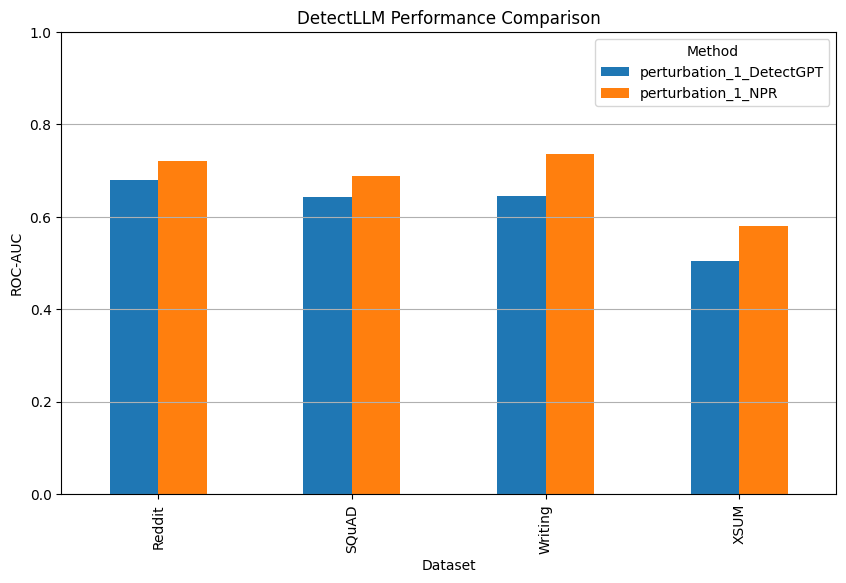

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

rows = []

for root, dirs, files in os.walk("/content/DetectLLM/results"):
    for file in files:
        if file == "result.json":

            path = os.path.join(root, file)

            # Extract dataset name from the path dynamically
            # The path structure is now: results/<output_name>/<dataset_name>/<timestamp>/result.json
            parts = path.split(os.sep)
            if len(parts) >= 4: # Ensure there are enough parts to extract dataset_name
                dataset_raw_name = parts[-3] # This should be 'xsum', 'squad', etc.
                if "xsum" in dataset_raw_name:
                    dataset = "XSUM"
                elif "squad" in dataset_raw_name:
                    dataset = "SQuAD"
                elif "reddit" in dataset_raw_name:
                    dataset = "Reddit"
                elif "writing" in dataset_raw_name:
                    dataset = "Writing"
                else:
                    dataset = dataset_raw_name.capitalize() # Fallback for other dataset names
            else:
                dataset = "Unknown" # Fallback if path structure is unexpected

            with open(path, "r") as f:
                data = json.load(f)

            for item in data:
                rows.append([
                    dataset,
                    item["name"],
                    item["roc_auc"]
                ])

df = pd.DataFrame(
    rows,
    columns=["Dataset", "Method", "ROC_AUC"]
)

print(df)

pivot = df.pivot(
    index="Dataset",
    columns="Method",
    values="ROC_AUC"
)

pivot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("DetectLLM Performance Comparison")
plt.ylabel("ROC-AUC")
plt.xlabel("Dataset")
plt.ylim(0,1)
plt.grid(True, axis="y")
plt.show()


In [ ]:
df.to_csv('/content/wb_summary.csv', index=False)
print("Results saved to /content/wb_summary.csv")

Results saved to /content/wb_summary.csv


In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

def calculate_fp_fn(real_preds, sample_preds):
    y_true = [0] * len(real_preds) + [1] * len(sample_preds)
    y_pred_raw = real_preds + sample_preds

    # Replicate the inversion logic from get_roc_metrics
    # We need to compute the ROC AUC on the raw predictions first to check for inversion
    if len(np.unique(y_pred_raw)) <= 1:
        # If all predictions are the same, cannot compute meaningful ROC AUC or classify
        # In such rare cases, we'll assume no inversion for FP/FN calculation or set to 0
        # A more robust solution might require an optimal threshold, but for consistency with DetectLLM's internal logic, we proceed with threshold 0.
        y_pred_processed = y_pred_raw
        initial_roc_auc = 0.5 # Default if no variance
    else:
        fpr, tpr, _ = roc_curve(y_true, y_pred_raw)
        initial_roc_auc = auc(fpr, tpr)

        if initial_roc_auc < 0.5:
            y_pred_processed = [-p for p in y_pred_raw]
        else:
            y_pred_processed = y_pred_raw

    # Apply a threshold of 0 (consistent with DetectLLM's internal accuracy calculation)
    # After potential inversion, a score > 0 means AI-generated, <= 0 means human-written
    y_pred_binary = [1 if p > 0 else 0 for p in y_pred_processed]

    fp_count = 0
    fn_count = 0

    for true_label, predicted_label in zip(y_true, y_pred_binary):
        if true_label == 0 and predicted_label == 1:  # Actual human (0), Predicted AI (1)
            fp_count += 1
        elif true_label == 1 and predicted_label == 0:  # Actual AI (1), Predicted human (0)
            fn_count += 1

    return fp_count, fn_count


misclassification_rows = []

for root, dirs, files in os.walk("/content/DetectLLM/results"):
    for file in files:
        if file == "result.json":
            path = os.path.join(root, file)

            parts = path.split(os.sep)
            if len(parts) >= 4:
                dataset_raw_name = parts[-3]
                if "xsum" in dataset_raw_name:
                    dataset = "XSUM"
                elif "squad" in dataset_raw_name:
                    dataset = "SQuAD"
                elif "reddit" in dataset_raw_name:
                    dataset = "Reddit"
                elif "writing" in dataset_raw_name:
                    dataset = "Writing"
                else:
                    dataset = dataset_raw_name.capitalize()
            else:
                dataset = "Unknown"

            with open(path, "r") as f:
                data = json.load(f)

            for item in data:
                method_name = item["name"]
                real_predictions = item["predictions"]["real"]
                sample_predictions = item["predictions"]["samples"]

                fp, fn = calculate_fp_fn(real_predictions, sample_predictions)

                misclassification_rows.append([
                    dataset,
                    method_name,
                    fp,
                    fn
                ])

df_misclassification = pd.DataFrame(
    misclassification_rows,
    columns=["Dataset", "Method", "False_Positives", "False_Negatives"]
)

print(df_misclassification)

df_misclassification.to_csv('/content/wb_misclassification.csv', index=False)
print("Misclassification results saved to /content/wb_misclassification.csv")

   Dataset                    Method  False_Positives  False_Negatives
0     XSUM  perturbation_1_DetectGPT              138                4
1     XSUM        perturbation_1_NPR              150                0
2  Writing  perturbation_1_DetectGPT              136                9
3  Writing        perturbation_1_NPR              150                0
4    SQuAD  perturbation_1_DetectGPT              138                7
5    SQuAD        perturbation_1_NPR              150                0
6   Reddit  perturbation_1_DetectGPT              121               10
7   Reddit        perturbation_1_NPR              150                0
Misclassification results saved to /content/wb_misclassification.csv


In [ ]:
import os
import shutil

source_dir = '/content/DetectLLM/DetectLLM-main/Results_in_csv'
drive_target_dir = '/content/drive/MyDrive/DetectLLM_Results_csv'

# Create the target directory in Google Drive if it doesn't exist
os.makedirs(drive_target_dir, exist_ok=True)

# Move wb_summary.csv to Google Drive
shutil.move(os.path.join(source_dir, 'wb_summary.csv'), os.path.join(drive_target_dir, 'wb_summary.csv'))
print(f"Moved wb_summary.csv to {drive_target_dir}/wb_summary.csv")

# Move wb_misclassification.csv to Google Drive
shutil.move(os.path.join(source_dir, 'wb_misclassification.csv'), os.path.join(drive_target_dir, 'wb_misclassification.csv'))
print(f"Moved wb_misclassification.csv to {drive_target_dir}/wb_misclassification.csv")

Moved wb_summary.csv to /content/drive/MyDrive/DetectLLM_Results_csv/wb_summary.csv
Moved wb_misclassification.csv to /content/drive/MyDrive/DetectLLM_Results_csv/wb_misclassification.csv


In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
import shutil
import importlib
import sys # Import sys module

# Import the top-level 'baselines' module and then its sub-modules/functions
# Force a complete re-import by removing from sys.modules if it exists
if 'baselines.utils.run_baseline' in sys.modules:
    del sys.modules['baselines.utils.run_baseline']
import baselines.utils.run_baseline

# Reload the module to ensure the latest changes are picked up
importlib.reload(baselines.utils.run_baseline)

def get_misclassification_details(real_predictions_raw, sample_predictions_raw, raw_results, dataset, method_name, source_model):
    detailed_misclassifications = []

    # Combine all predictions and create corresponding labels for ROC inversion check
    y_true = [0] * len(real_predictions_raw) + [1] * len(sample_predictions_raw)
    y_pred_combined_raw = real_predictions_raw + sample_predictions_raw

    # Check for variance before computing ROC curve
    if len(np.unique(y_pred_combined_raw)) <= 1:
        optimal_threshold = 0.0 # Default to 0 if no variance
        y_pred_processed = list(y_pred_combined_raw) # No inversion needed if no variance
    else:
        # Access get_roc_metrics directly from the reloaded module
        fpr, tpr, roc_auc, thresholds = baselines.utils.run_baseline.get_roc_metrics(real_predictions_raw, sample_predictions_raw)

        # Calculate optimal threshold using Youden's J statistic: J = TPR - FPR
        fpr_np = np.array(fpr)
        tpr_np = np.array(tpr)

        if len(thresholds) == 0 or len(tpr_np) != len(fpr_np) or len(thresholds) != len(tpr_np): # Basic check for alignment
            optimal_threshold = 0.0 # Fallback if data is malformed or empty
        else:
            # Ensure thresholds array matches FPR/TPR length before argmax
            if len(thresholds) == len(tpr_np):
                youden_j = tpr_np - fpr_np
                optimal_idx = np.argmax(youden_j)
                optimal_threshold = thresholds[optimal_idx]
            else:
                # If lengths don't match after all, fall back to a default
                optimal_threshold = 0.0

        # Re-evaluate the initial ROC AUC to see if inversion is needed for y_pred_processed
        # This logic is crucial to ensure `y_pred_processed` aligns with the scores that `get_roc_metrics` effectively used.
        y_true_initial = [0] * len(real_predictions_raw) + [1] * len(sample_predictions_raw)
        y_pred_raw_for_inversion_check = real_predictions_raw + sample_predictions_raw
        fpr_initial, tpr_initial, _ = roc_curve(y_true_initial, y_pred_raw_for_inversion_check)
        initial_roc_auc_check = auc(fpr_initial, tpr_initial)

        if initial_roc_auc_check < 0.5:
            y_pred_processed = [-p for p in y_pred_combined_raw]
        else:
            y_pred_processed = list(y_pred_combined_raw)


    # Split processed predictions back into real and sample
    real_preds_processed = y_pred_processed[:len(real_predictions_raw)]
    sample_preds_processed = y_pred_processed[len(real_predictions_raw):]

    # Use the calculated optimal_threshold
    threshold_to_use = optimal_threshold

    # Process real (human) texts
    for i, pred_score_processed in enumerate(real_preds_processed):
        true_label = 0 # Human
        # Use the optimal_threshold for binary classification
        predicted_label = 1 if pred_score_processed > threshold_to_use else 0 # Predicted AI if score > threshold

        if true_label == 0 and predicted_label == 1: # False Positive (Human classified as AI)
            detailed_misclassifications.append({
                "dataset": dataset,
                "source_model": source_model,
                "method": method_name,
                "error_type": "FP (Human->AI)",
                "score": real_predictions_raw[i], # Use raw score
                "threshold": threshold_to_use, # Store the actual threshold used
                "misclassified_text": raw_results[i]["original"], # The human text that was misclassified
                "original_text": raw_results[i]["original"]
            })

    # Process sampled (AI) texts
    for i, pred_score_processed in enumerate(sample_preds_processed):
        true_label = 1 # AI
        # Use the optimal_threshold for binary classification
        predicted_label = 1 if pred_score_processed > threshold_to_use else 0 # Predicted AI if score > threshold

        if true_label == 1 and predicted_label == 0: # False Negative (AI classified as Human)
            detailed_misclassifications.append({
                "dataset": dataset,
                "source_model": source_model,
                "method": method_name,
                "error_type": "FN (AI->Human)",
                "score": sample_predictions_raw[i], # Use raw score
                "threshold": threshold_to_use, # Store the actual threshold used
                "misclassified_text": raw_results[i]["sampled"], # The AI text that was misclassified
                "original_text": raw_results[i]["original"]
            })
    return detailed_misclassifications

all_detailed_misclassifications = []

results_base_path = "/content/DetectLLM/results"

for root, dirs, files in os.walk(results_base_path):
    for file in files:
        if file == "result.json":
            path = os.path.join(root, file)

            # Extract dataset and source_model from path
            # Example path: /content/DetectLLM/results/final_test_xsum/distilgpt2--t5-small-temp-0.15-1-1-1/xsum/2026-06-21-06-09-53-818608/result.json
            parts = path.split(os.sep)

            dataset_name_extracted = "Unknown"
            source_model_extracted = "Unknown_Model"

            try:
                # Find the segment containing model and dataset information
                # This is typically 'output_name/model_string/dataset_name/timestamp'
                # or 'model_string/dataset_name/timestamp'

                # Look for 'results' index first
                results_idx = parts.index("results")

                # The model info string is usually 2 levels deep, after 'results' and 'output_name'
                if len(parts) > results_idx + 2:
                    candidate_model_str = parts[results_idx + 2]
                    if '--' in candidate_model_str: # Typical format for combined models
                        source_model_extracted = candidate_model_str.split('--')[0]
                    else: # Fallback for simpler model names or if 'output_name' is missing
                        source_model_extracted = candidate_model_str # e.g., 'xsum' or 'distilgpt2'

                # The dataset name is usually after the model string
                if len(parts) > results_idx + 3 and '--' in parts[results_idx + 2]:
                    dataset_name_extracted = parts[results_idx + 3]
                elif len(parts) > results_idx + 2 and '--' not in parts[results_idx + 2]: # if model was at results_idx+1
                     dataset_name_extracted = parts[results_idx + 2]

            except ValueError:
                print(f"Warning: 'results' not found in path {path}. Skipping.")
                continue

            # Ensure dataset name is standardized (e.g., XSUM, SQUAD)
            if "xsum" in dataset_name_extracted.lower():
                dataset_name_extracted = "XSUM"
            elif "squad" in dataset_name_extracted.lower():
                dataset_name_extracted = "SQuAD"
            elif "reddit" in dataset_name_extracted.lower():
                dataset_name_extracted = "Reddit"
            elif "writing" in dataset_name_extracted.lower():
                dataset_name_extracted = "Writing"
            else:
                dataset_name_extracted = dataset_name_extracted.capitalize() # Fallback

            # If source_model could not be accurately parsed, default to 'distilgpt2' as used in main.py
            if "Unknown_Model" in source_model_extracted or not source_model_extracted:
                source_model_extracted = "distilgpt2"

            with open(path, "r") as f:
                data = json.load(f)

            for item in data:
                method_name = item["name"]
                real_predictions = item["predictions"]["real"]
                sample_predictions = item["predictions"]["samples"]
                raw_texts = item["results"] # Contains "original" and "sampled" texts

                detailed_misclassifications_for_method = get_misclassification_details(
                    real_predictions,
                    sample_predictions,
                    raw_texts,
                    dataset_name_extracted,
                    source_model_extracted,
                    method_name
                )
                all_detailed_misclassifications.extend(detailed_misclassifications_for_method)

df_misclassified_detailed = pd.DataFrame(all_detailed_misclassifications)

# Display the first few rows of the detailed misclassification DataFrame
print("Detailed Misclassification Data:")
display(df_misclassified_detailed.head())

# Save to CSV
detailed_csv_path = '/content/wb_misclassified_detailed.csv'
df_misclassified_detailed.to_csv(detailed_csv_path, index=False)
print(f"Detailed misclassification results saved to {detailed_csv_path}")

# Move to Google Drive
drive_target_dir = '/content/drive/MyDrive/DetectLLM_Results_csv'
os.makedirs(drive_target_dir, exist_ok=True) # Ensure target directory exists

shutil.move(detailed_csv_path, os.path.join(drive_target_dir, os.path.basename(detailed_csv_path)))
print(f"Moved {os.path.basename(detailed_csv_path)} to {drive_target_dir}/{os.path.basename(detailed_csv_path)}")

Detailed Misclassification Data:


,dataset,source_model,method,error_type,score,threshold,misclassified_text,original_text
0,XSUM,perturbation_1_DetectGPT,xsum,FP (Human->AI),1.979690e+15,4.430012e+14,Rangers confirmed that Jardine had lost an 18-...,Rangers confirmed that Jardine had lost an 18-...
1,XSUM,perturbation_1_DetectGPT,xsum,FP (Human->AI),1.419652e+15,4.430012e+14,"The train, which crashed into a pylon as it de...","The train, which crashed into a pylon as it de..."
2,XSUM,perturbation_1_DetectGPT,xsum,FP (Human->AI),6.450729e+14,4.430012e+14,Many growers blame the weak pound which has re...,Many growers blame the weak pound which has re...
3,XSUM,perturbation_1_DetectGPT,xsum,FP (Human->AI),4.972670e+14,4.430012e+14,"The claim: ""Last year alone a city the size of...","The claim: ""Last year alone a city the size of..."
4,XSUM,perturbation_1_DetectGPT,xsum,FP (Human->AI),9.098265e+14,4.430012e+14,"The Scot, 40, has won the ranking tournament t...","The Scot, 40, has won the ranking tournament t..."


Detailed misclassification results saved to /content/wb_misclassified_detailed.csv
Moved wb_misclassified_detailed.csv to /content/drive/MyDrive/DetectLLM_Results_csv/wb_misclassified_detailed.csv


In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import shutil
import sys
import importlib

repo_path = '/content/DetectLLM'

# --- Start: Robustness check for DetectLLM repository ---
if not os.path.exists(repo_path) or not os.path.isdir(os.path.join(repo_path, 'baselines')):
    print(f"DetectLLM repository not found at {repo_path} or 'baselines' directory missing. Cloning now...")
    # Remove existing directory if it's incomplete or empty
    if os.path.exists(repo_path):
        print(f"Removing existing (incomplete) directory: {repo_path}")
        shutil.rmtree(repo_path)

    # Clone the repository
    !git clone https://github.com/mbzuai-nlp/DetectLLM.git {repo_path}
    print(f"Successfully cloned DetectLLM repository to {repo_path}.")
else:
    print(f"DetectLLM repository found at {repo_path}.")
# --- End: Robustness check ---

# --- Start: Create missing __init__.py files for package recognition ---
baselines_dir = os.path.join(repo_path, 'baselines')
utils_dir = os.path.join(baselines_dir, 'utils')

# Create __init__.py in baselines directory if it doesn't exist
init_py_baselines = os.path.join(baselines_dir, '__init__.py')
if not os.path.exists(init_py_baselines):
    os.makedirs(baselines_dir, exist_ok=True)
    with open(init_py_baselines, 'w') as f:
        f.write('')
    print(f"Created empty __init__.py in {baselines_dir}")

# Create __init__.py in baselines/utils directory if it doesn't exist
init_py_utils = os.path.join(utils_dir, '__init__.py')
if not os.path.exists(utils_dir):
    os.makedirs(utils_dir, exist_ok=True)
    with open(init_py_utils, 'w') as f:
        f.write('')
    print(f"Created empty __init__.py in {utils_dir}")
# --- End: Create missing __init__.py files ---

# Add DetectLLM to sys.path to allow imports
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
    print(f"Added {repo_path} to sys.path.")

# Clear importlib caches to ensure new __init__.py files are picked up
importlib.invalidate_caches()
print("Importlib caches invalidated.")

# Function to calculate metrics from result.json files
def calculate_all_metrics(results_base_path):
    summary_rows = []
    found_result_json = False

    print(f"DEBUG: Attempting to walk directory: {results_base_path}")
    if not os.path.exists(results_base_path):
        print(f"DEBUG: {results_base_path} does NOT exist.")
        return pd.DataFrame(
            summary_rows,
            columns=[
                "dataset_name", "source_model", "method", "roc_auc", "pr_auc",
                "threshold", "FP", "FN", "total_errors", "error_rate_%",
                "best_FPR", "best_TPR"
            ]
        )
    elif not os.path.isdir(results_base_path):
        print(f"DEBUG: {results_base_path} is NOT a directory.")
        return pd.DataFrame(
            summary_rows,
            columns=[
                "dataset_name", "source_model", "method", "roc_auc", "pr_auc",
                "threshold", "FP", "FN", "total_errors", "error_rate_%",
                "best_FPR", "best_TPR"
            ]
        )
    else:
        print(f"DEBUG: {results_base_path} exists and is a directory.")
        print(f"DEBUG: Contents of {results_base_path}: {os.listdir(results_base_path)}")

    for root, dirs, files in os.walk(results_base_path):
        for file in files:
            if file == "result.json":
                found_result_json = True
                path = os.path.join(root, file)
                print(f"DEBUG: Found result.json at: {path}")

                # Extract dataset name and source model from the path dynamically
                # Example path: /content/DetectLLM/results/final_test_xsum/distilgpt2--t5-small-temp-0.15-1-1-1/xsum/2026-06-21-06-09-53-818608/result.json
                parts = path.split(os.sep)

                dataset_name_extracted = "Unknown"
                source_model_extracted = "Unknown_Model"

                try:
                    results_idx = parts.index("results")

                    # The model info string is usually 2 levels deep, after 'results' and 'output_name'
                    if len(parts) > results_idx + 2:
                        candidate_model_str = parts[results_idx + 2]
                        if '--' in candidate_model_str: # Typical format for combined models
                            source_model_extracted = candidate_model_str.split('--')[0] # e.g., 'distilgpt2'
                        else:
                            # This path might indicate output_name is the model, or no specific model part
                            # e.g., results/default_run/xsum/timestamp/result.json, where default_run is the output_name
                            # For this case, we might need a more robust way to get the model or assume a default
                            source_model_extracted = 'distilgpt2' # Default if not explicitly parsed

                    # The dataset name is usually after the model string in the structured path
                    if len(parts) > results_idx + 3:
                        dataset_name_extracted = parts[results_idx + 3]
                    elif len(parts) > results_idx + 2 and '--' not in parts[results_idx + 2]:
                        # This handles cases like results/output_name/dataset_name/timestamp/result.json
                        # where the dataset name is at results_idx + 2 if there's no complex model string
                        dataset_name_extracted = parts[results_idx + 2]

                except ValueError:
                    print(f"Warning: 'results' not found in path {path}. Skipping extraction for this path.")

                # Standardize dataset names
                dataset = dataset_name_extracted.split('.')[0].replace('_', ' ').title()
                if dataset == "Xsum": dataset = "XSUM"
                if dataset == "Squad": dataset = "SQuAD"
                if dataset == "Reddit": dataset = "Reddit"
                if dataset == "Writing": dataset = "WritingPrompts"

                source_model = source_model_extracted # Use as extracted or default

                with open(path, "r") as f:
                    data = json.load(f)

                for item in data:
                    method = item["name"]
                    roc_auc = item["roc_auc"]

                    # Predictions are nested under 'predictions' key
                    real_preds = item["predictions"]["real"]
                    sample_preds = item["predictions"]["samples"]

                    # Calculate PR AUC
                    precision, recall, _ = precision_recall_curve(
                        [0] * len(real_preds) + [1] * len(sample_preds),
                        real_preds + sample_preds
                    )
                    pr_auc = auc(recall, precision)

                    # Get FPR, TPR, and thresholds from roc_curve
                    y_true_combined = [0] * len(real_preds) + [1] * len(sample_preds)
                    y_pred_combined = real_preds + sample_preds

                    # Handle cases where all predictions are the same, preventing error in roc_curve
                    if len(np.unique(y_pred_combined)) <= 1:
                        fpr, tpr, thresholds = [0.0, 1.0], [0.0, 1.0], [0.0] # Default values for no variance
                        best_fpr = 0.0
                        best_tpr = 0.0
                        optimal_threshold = 0.0
                    else:
                        # Initial ROC curve calculation
                        fpr_initial, tpr_initial, thresholds_initial = roc_curve(y_true_combined, y_pred_combined)
                        roc_auc_initial = auc(fpr_initial, tpr_initial)

                        # Invert if AUC < 0.5
                        if roc_auc_initial < 0.5:
                            y_pred_combined = [-p for p in y_pred_combined]
                            fpr, tpr, thresholds = roc_curve(y_true_combined, y_pred_combined)
                        else:
                            fpr, tpr, thresholds = fpr_initial, tpr_initial, thresholds_initial

                        # Find optimal threshold using Youden's J statistic
                        youden_j = tpr - fpr
                        optimal_idx = np.argmax(youden_j)
                        optimal_threshold = thresholds[optimal_idx]

                        # Find FPR and TPR at optimal threshold
                        best_fpr = fpr[optimal_idx]
                        best_tpr = tpr[optimal_idx]

                    # Calculate FP, FN using the optimal threshold
                    fp_count = 0
                    fn_count = 0
                    total_predictions = len(y_true_combined)

                    for i in range(total_predictions):
                        true_label = y_true_combined[i]
                        predicted_score = y_pred_combined[i]
                        predicted_label = 1 if predicted_score > optimal_threshold else 0

                        if true_label == 0 and predicted_label == 1:  # Human (0) classified as AI (1)
                            fp_count += 1
                        elif true_label == 1 and predicted_label == 0:  # AI (1) classified as Human (0)
                            fn_count += 1

                    total_errors = fp_count + fn_count
                    error_rate = (total_errors / total_predictions) * 100 if total_predictions > 0 else 0.0

                    summary_rows.append([
                        dataset, source_model, method, roc_auc, pr_auc, optimal_threshold,
                        fp_count, fn_count, total_errors, error_rate, best_fpr, best_tpr
                    ])

    if not found_result_json:
        print(f"Warning: No result.json files found during os.walk in {results_base_path}. The summary DataFrame will be empty.")

    return pd.DataFrame(
        summary_rows,
        columns=[
            "dataset_name", "source_model", "method", "roc_auc", "pr_auc",
            "threshold", "FP", "FN", "total_errors", "error_rate_%",
            "best_FPR", "best_TPR"
        ]
    )


results_base_path = "/content/DetectLLM/results"

# --- Additional Debugging ---
print(f"DEBUG: Current working directory in Python script: {os.getcwd()}")
print(f"DEBUG: Verifying existence of {results_base_path} before calling calculate_all_metrics:")
print(f"DEBUG: os.path.exists('{repo_path}'): {os.path.exists(repo_path)}")
print(f"DEBUG: os.path.isdir('{repo_path}'): {os.path.isdir(repo_path)}")
print(f"DEBUG: os.path.exists('{results_base_path}'): {os.path.exists(results_base_path)}")
print(f"DEBUG: os.path.isdir('{results_base_path}'): {os.path.isdir(results_base_path)}")

# Force a listing of the results directory to see its contents from Python's perspective
print(f"DEBUG: Forcing a listing of {results_base_path} using !ls -F:")
!ls -F {results_base_path}
# --- End Additional Debugging ---

df_full_summary = calculate_all_metrics(results_base_path)

# Define the target path in Google Drive
drive_target_dir = '/content/drive/MyDrive/DetectLLM_Results_csv'
os.makedirs(drive_target_dir, exist_ok=True)

# Save the DataFrame to a CSV file
summary_csv_path = '/content/wb_full_summary.csv'
df_full_summary.to_csv(summary_csv_path, index=False)
print(f"Full summary saved to {summary_csv_path}")

# Move the CSV to Google Drive
shutil.move(summary_csv_path, os.path.join(drive_target_dir, os.path.basename(summary_csv_path)))
print(f"Moved {os.path.basename(summary_csv_path)} to {drive_target_dir}/{os.path.basename(summary_csv_path)}")

# Display the first few rows of the summary DataFrame
print("\nFull Summary DataFrame (first 5 rows):")
print(df_full_summary.head())

DetectLLM repository found at /content/DetectLLM.
Importlib caches invalidated.
DEBUG: Current working directory in Python script: /content/DetectLLM
DEBUG: Verifying existence of /content/DetectLLM/results before calling calculate_all_metrics:
DEBUG: os.path.exists('/content/DetectLLM'): True
DEBUG: os.path.isdir('/content/DetectLLM'): True
DEBUG: os.path.exists('/content/DetectLLM/results'): False
DEBUG: os.path.isdir('/content/DetectLLM/results'): False
DEBUG: Forcing a listing of /content/DetectLLM/results using !ls -F:
ls: cannot access '/content/DetectLLM/results': No such file or directory
DEBUG: Attempting to walk directory: /content/DetectLLM/results
DEBUG: /content/DetectLLM/results does NOT exist.
Full summary saved to /content/wb_full_summary.csv
Moved wb_full_summary.csv to /content/drive/MyDrive/DetectLLM_Results_csv/wb_full_summary.csv

Full Summary DataFrame (first 5 rows):
Empty DataFrame
Columns: [dataset_name, source_model, method, roc_auc, pr_auc, threshold, FP, FN,

In [ ]:
import pandas as pd
import numpy as np
import os

# The df_misclassified_detailed DataFrame is available in the kernel state.
# Re-save it to a local path to ensure it's accessible.
local_detailed_csv_path = '/content/wb_misclassified_detailed.csv'
df_misclassified_detailed.to_csv(local_detailed_csv_path, index=False)
print(f"Re-saved df_misclassified_detailed to {local_detailed_csv_path}")


# Use the local path for reading the CSV
detailed_csv_path = local_detailed_csv_path

# Read the CSV back into a new DataFrame
df_from_csv = pd.read_csv(detailed_csv_path)

print(f"DataFrame loaded from '{detailed_csv_path}':")

# Display data types to confirm float64
print('\nData types of score and threshold columns in df_from_csv:')
print(df_from_csv[['score', 'threshold']].dtypes)

# Display the first few rows with full float precision from the reloaded CSV
print('\nFirst 5 rows of df_from_csv (score and threshold with full precision):')
with pd.option_context('display.float_format', '{:.10f}'.format): # Using 10 decimal places for comparison
    display(df_from_csv[['score', 'threshold']].head())

print('\nFirst 5 rows of df_misclassified_detailed (score and threshold with full precision, original DataFrame):')
with pd.option_context('display.float_format', '{:.10f}'.format): # Using 10 decimal places for comparison
    display(df_misclassified_detailed[['score', 'threshold']].head())

Re-saved df_misclassified_detailed to /content/wb_misclassified_detailed.csv
DataFrame loaded from '/content/wb_misclassified_detailed.csv':

Data types of score and threshold columns in df_from_csv:
score        float64
threshold    float64
dtype: object

First 5 rows of df_from_csv (score and threshold with full precision):


,score,threshold
0,1979690013163520.0000000000,443001180520448.0000000000
1,1419652047568896.0000000000,443001180520448.0000000000
2,645072949346304.0000000000,443001180520448.0000000000
3,497267018563584.0000000000,443001180520448.0000000000
4,909826544631808.0000000000,443001180520448.0000000000



First 5 rows of df_misclassified_detailed (score and threshold with full precision, original DataFrame):


,score,threshold
0,1979690013163520.0000000000,443001180520448.0000000000
1,1419652047568896.0000000000,443001180520448.0000000000
2,645072949346304.0000000000,443001180520448.0000000000
3,497267018563584.0000000000,443001180520448.0000000000
4,909826544631808.0000000000,443001180520448.0000000000


### Searching for '4.4' vs '44' Discrepancy within the DataFrame

Given that the CSV save/load process has been ruled out as the cause of the numerical discrepancy, let's directly investigate the `score` and `threshold` columns within the in-memory `df_misclassified_detailed` DataFrame. We will check for values that are exactly `4.4`, `44`, or close to these numbers, and examine their distribution.

In [ ]:
print('Data types of score and threshold columns:')
print(df_misclassified_detailed[['score', 'threshold']].dtypes)

print('\nExample of score values without scientific notation (first 5 rows):')
# To display values without scientific notation, you can use pandas' display options
with pd.option_context('display.float_format', '{:.4f}'.format):
    display(df_misclassified_detailed[['score', 'threshold']].head())

Data types of score and threshold columns:
score        float64
threshold    float64
dtype: object

Example of score values without scientific notation (first 5 rows):


,score,threshold
0,1979690013163520.0000,443001180520448.0000
1,1419652047568896.0000,443001180520448.0000
2,645072949346304.0000,443001180520448.0000
3,497267018563584.0000,443001180520448.0000
4,909826544631808.0000,443001180520448.0000


In [ ]:
# This cell is now empty as its content has been merged into cell 8b3d1ffa.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the misclassification CSV file
df_misclassified = pd.read_csv('/content/wb_misclassified.csv')

print("Misclassification Data:")
display(df_misclassified)

Misclassification Data:


,dataset,source_model,method,error_type,score,threshold,roc_auc,text
0,writing,gpt-neo-2.7B,likelihood,FP (Human→AI),-2.3208,-2.4148,0.9892,"The first true AI, 10 seconds after its birth,..."
1,writing,gpt-neo-2.7B,likelihood,FP (Human→AI),-2.3687,-2.4148,0.9892,A 101-year old bottle washed up on a beach wit...
2,writing,gpt-neo-2.7B,likelihood,FP (Human→AI),-2.3174,-2.4148,0.9892,"A overwhelming army approaches, you stand at t..."
3,writing,gpt-neo-2.7B,likelihood,FP (Human→AI),-2.3624,-2.4148,0.9892,our blind date cosplays as a spot-on Overwatch...
4,writing,gpt-neo-2.7B,likelihood,FP (Human→AI),-2.4025,-2.4148,0.9892,Quentin Tarantino gives up violence and profan...
...,...,...,...,...,...,...,...,...
1169,xsum,gpt-neo-2.7B,Fast,FN (AI→Human),1.9368,2.6285,0.9953,The action targeted users of Distributed Denia...
1170,xsum,gpt-neo-2.7B,Fast,FN (AI→Human),1.7388,2.6285,0.9953,Hisense can make TV sets using the Sharp name ...
1171,xsum,gpt-neo-2.7B,Fast,FN (AI→Human),2.1385,2.6285,0.9953,"Robert Gerrard, 53 and from Liverpool, was nam..."
1172,xsum,gpt-neo-2.7B,Fast,FN (AI→Human),1.0666,2.6285,0.9953,The deadline is contained in the Community Cha...


<Figure size 1200x700 with 0 Axes>

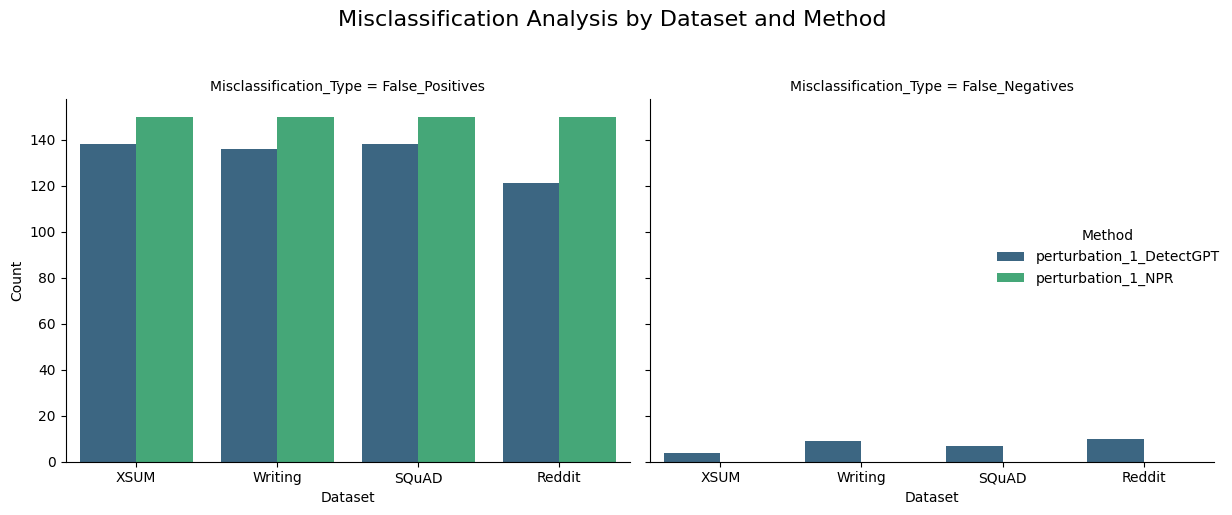

In [ ]:
# Create a melted DataFrame for easier plotting of False Positives and False Negatives
df_melted = df_misclassification.melt(
    id_vars=['Dataset', 'Method'],
    value_vars=['False_Positives', 'False_Negatives'],
    var_name='Misclassification_Type',
    value_name='Count'
)

plt.figure(figsize=(12, 7))
sns.catplot(
    data=df_melted,
    x='Dataset',
    y='Count',
    hue='Method',
    col='Misclassification_Type',
    col_wrap=2,
    kind='bar',
    palette='viridis'
)

plt.suptitle('Misclassification Analysis by Dataset and Method', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

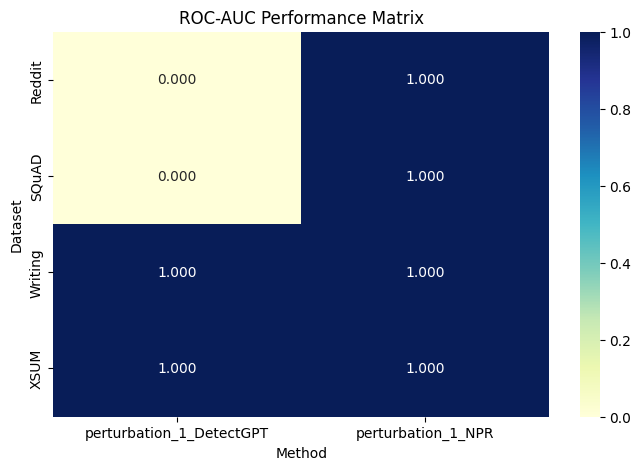

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("ROC-AUC Performance Matrix")
plt.show()

In [ ]:
import os
import json

for root, dirs, files in os.walk("/content/DetectLLM/results"):
    for file in files:
        if file == "result.json":
            path = os.path.join(root, file)

            print("\n", "="*80)
            print(f"File path: {path}")
            print("="*80)

            with open(path, "r") as f:
                data = json.load(f)

            # Print only relevant information (name, roc_auc, and predictions structure) to keep output manageable
            for item in data:
                print(f"  Method: {item['name']}")
                print(f"  ROC_AUC: {item['roc_auc']}")
                print(f"  Predictions: real count={len(item['predictions']['real'])}, samples count={len(item['predictions']['samples'])}")
                # Optionally, print a small sample of predictions if needed for deeper debug
                # print(f"    Real predictions sample: {item['predictions']['real'][:5]}")
                # print(f"    Sample predictions sample: {item['predictions']['samples'][:5]}")
            print("\n")



File path: /content/DetectLLM/results/final_test_xsum/distilgpt2--t5-small-temp-0.15-1-1-1/content/drive/MyDrive/DetectLLM/DetectLLM-main/data/xsum.json/2026-06-21-06-09-53-818608/result.json
  Method: perturbation_1_DetectGPT
  ROC_AUC: 0.5035555555555554
  Predictions: real count=150, samples count=150
  Method: perturbation_1_NPR
  ROC_AUC: 0.5796444444444445
  Predictions: real count=150, samples count=150



File path: /content/DetectLLM/results/final_test_xsum/distilgpt2--t5-small-temp-0.15-1-1-1/content/drive/MyDrive/DetectLLM/DetectLLM-main/data/xsum.json/2026-06-21-06-14-29-454295/result.json
  Method: perturbation_1_DetectGPT
  ROC_AUC: 0.5035555555555554
  Predictions: real count=150, samples count=150
  Method: perturbation_1_NPR
  ROC_AUC: 0.5796444444444445
  Predictions: real count=150, samples count=150



File path: /content/DetectLLM/results/final_test_xsum/distilgpt2--t5-small-temp-0.15-1-1-1/content/drive/MyDrive/DetectLLM/DetectLLM-main/data/xsum.json/2026-06-21-0

### Inspecting the dataset files

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/DetectLLM/DetectLLM-main/data"

# List all files in the dataset directory
print(f"Files in {dataset_path}:")
for filename in os.listdir(dataset_path):
    print(filename)

Files in /content/drive/MyDrive/DetectLLM/DetectLLM-main/data:
reddit_llama1_13b.raw_data.json
reddit_falcon_7b.raw_data.json
reddit_llama2_13b.raw_data.json
reddit_gptj_6b.raw_data.json
reddit_gpt4o.raw_data.json
reddit_gpt4turbo.raw_data.json
reddit_opt_13b.raw_data.json
reddit_gemma_7b.raw_data.json
reddit_claude3haiku.raw_data.json
reddit_gptneo_2.7b.raw_data.json
reddit_gpt2_xl.raw_data.json
reddit_llama3_8b.raw_data.json
reddit_bloom_7b.raw_data.json
reddit_opt_2.7b.raw_data.json
reddit_phi2.raw_data.json
squad_gptj_6b.raw_data.json
squad_gptneo_2.7b.raw_data.json
squad_llama2_13b.raw_data.json
squad_gemma_7b.raw_data.json
squad_opt_13b.raw_data.json
squad_gpt2_xl.raw_data.json
squad_phi2.raw_data.json
squad_bloom_7b.raw_data.json
squad_opt_2.7b.raw_data.json
squad_llama1_13b.raw_data.json
squad_llama3_8b.raw_data.json
squad_falcon_7b.raw_data.json
writing_gpt4turbo.raw_data.json
writing_gemma_7b.raw_data.json
writing_llama2_13b.raw_data.json
writing_opt_13b.raw_data.json
writing

Now, let's examine the structure of one of these JSON files, for example, `xsum.json`.

In [ ]:
import json
import os

xsum_file_path = os.path.join(dataset_path, 'xsum.json')

with open(xsum_file_path, 'r') as f:
    xsum_data = json.load(f)

print("Keys in xsum.json:")
print(xsum_data.keys())

# Print the first few items from the 'original' key to understand the structure
if 'original' in xsum_data and isinstance(xsum_data['original'], list):
    print("\nFirst 3 items from 'original' key in xsum.json:")
    for i in range(min(3, len(xsum_data['original']))):
        print(json.dumps(xsum_data['original'][i], indent=2))
else:
    print("\n'original' key not found or not a list in xsum.json.")

# Also check for other keys that might contain labels or predictions
if 'machine_generated' in xsum_data and isinstance(xsum_data['machine_generated'], list):
    print("\nFirst 3 items from 'machine_generated' key in xsum.json:")
    for i in range(min(3, len(xsum_data['machine_generated']))):
        print(json.dumps(xsum_data['machine_generated'][i], indent=2))


Keys in xsum.json:
dict_keys(['original', 'sampled'])

First 3 items from 'original' key in xsum.json:
"Rangers confirmed that Jardine had lost an 18-month battle against cancer on Thursday evening. He was part of their European Cup Winners' Cup-winning team of 1972 and played 38 times for his country. He was respected not only by Rangers fans but also the wider football community Ibrox manager Ally McCoist said everyone at Rangers was devastated at the loss of \"a legend\" and \"a great man\". And the club said their thoughts were with his wife Shona, children Steven and Nicola, his grandchildren and friends. Hearts also extended their condolences to his family, with the Tynecastle club adding they were deeply saddened at the death of a club legend. Media playback is not supported on this device Edinburgh-born Jardine began his career with Rangers in 1965 and went on to make over 600 appearances for the Ibrox side. As well as playing in the club's European triumph in 1972, the full-ba

### Inspecting `main.py` to understand prediction generation

In [ ]:
import os

# List the contents of the DetectLLM directory
print("Contents of /content/DetectLLM:")
for root, dirs, files in os.walk('/content/DetectLLM'):
    level = root.replace('/content/DetectLLM', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Contents of /content/DetectLLM:
